## 1.0 Background Information

## 2.0 Environment & Imports

In [18]:
# Import the necessary packages and libraries.
import sys, os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML

# Print versions for loaded packages and libraries.
print()
try:
    print (f"sys: Version {sys.version}")
    print(f"numpy: Version {np.__version__}")
    print(f"pandas: Version {pd.__version__}")
    print(f"matplotlib: Version {plt.matplotlib.__version__}")
    print(f"seaborn: Version {sns.__version__}")
except NameError:
    print("One or more libraries failed to load — check errors above.")

# Add the project root to Python's path so src/ modules can be imported across all machines.
sys.path.append(os.path.abspath('..'))

from src.yieldcurve import YieldCurve
from src.derivative_test import EuropeanCall, EuropeanPut
from src.portfolio_test import EquityPosition, Portfolio

# For consistency, display all float values to 4 decimal places (unless specifically formatted differently).
pd.set_option ("display.float_format", "{:.4f}".format)


sys: Version 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
numpy: Version 2.4.4
pandas: Version 3.0.3
matplotlib: Version 3.10.9
seaborn: Version 0.13.2


## 3.0 Create Instrument Objects

For tutorial purposes, we use:

- One equity position
- One European Call
- One European Put

NOTE: This is only a smoke test for the portfolio risk layer. 

Your final A3 portfolio should be chosen and justified by your group.

In [19]:
curve = YieldCurve.from_rba (compounding = "continuous")

equity = EquityPosition (ticker = "DEMO_STOCK", spot = 100.0) # We might want to put quantity in here as well, but for now we can assume 1 share.

call = EuropeanCall (
    S0 = 100.0, # Stock price at Time 0.
    K = 105.0, # Strike price.
    T = 0.5, # Time to maturity in years.
    sigma = 0.20, # Volatility (20%)
    yield_curve = curve
)

put = EuropeanPut (
    S0 = 100.0,
    K = 95.0, 
    T = 0.5,
    sigma = 0.20,
    yield_curve = curve
)

[data_loader] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\F17_DATA_CLEAN.csv


## 4.0 Sanity-Check Instrument Pricing

Before creating the portfolio, we check that each instrument works individually.

In [20]:
print ("Equity Price:", round(equity.price(), 4))
print ("Equity Delta:", round (equity.delta(), 4))

print ("Call Price:", round (call.price(), 4))
print ("Call Delta:", round (call.delta(), 4))

print ("Put Price:", round (put.price(), 4))
print ("Put Delta:", round (put.delta(), 4))

Equity Price: 100.0
Equity Delta: 1.0
Call Price: 4.4704
Call Delta: 0.4536
Put Price: 2.6081
Put Delta: -0.2772


## 5.0 Create the Portfolio Object

Now we move from instrument pricing to portfolio management.

In [21]:
portfolio = Portfolio()

portfolio.add_position (equity, quantity = 100, label = "Long Equity")
portfolio.add_position (call, quantity = 10, label = "Long Call")
portfolio.add_position (put, quantity = 5, label = "Short Put")

## 6.0 Show the Portfolio Position

This is the first dashboard-style output.

It shows:

- What is held
- In what quantity
- What each position is worth,
- How each position contributes to delta.

In [22]:
position_df = portfolio.position_table ()
position_df

,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,Long Equity,100.0000,100.0000,10000.0000,1.0000,100.0000
1,Long Call,10.0000,4.4704,44.7041,0.4536,4.5359
2,Short Put,5.0000,2.6081,13.0405,-0.2772,-1.3861
3,TOTAL,NaN,NaN,10057.7446,NaN,103.1497


## 7.0 Compute Core Portfolio Returns

At a minimum, the portfolio risk layer should provide:

- Total portfolio value
- Total portfolio delta

In [23]:
portfolio_value = portfolio.value()
portfolio_delta = portfolio.delta()

print ("Portfolio Value:", round (portfolio_value, 2))
print ("Portfolio Delta:", round (portfolio_delta, 4))

Portfolio Value: 10057.74
Portfolio Delta: 103.1497


## 8.0 Compute a Basic Historical VaR

For tutorial pruposes, we use a small toy histoical return series. 

In your final A3 project, you should use documented historical return series from your chosen workflow. 

In [24]:
toy_returns = pd.Series ([
    -0.025, -0.018, -0.012, -0.009, -0.004,
    0.001, 0.004, 0.006, 0.010, 0.015
])

In [25]:
hist_var_975 = portfolio.historical_var (toy_returns, alpha = 0.975, horizon_days = 1)
hist_var_95 = portfolio.historical_var (toy_returns, alpha = 0.95, horizon_days = 1)
hist_var_90 = portfolio.historical_var (toy_returns, alpha = 0.90, horizon_days = 1)

print ("Historical VaR (97.5%, 1-day):", round (hist_var_975, 2))
print ("Historical VaR (95%, 1-day):", round (hist_var_95, 2))
print ("Historical VaR (90%, 1-day):", round (hist_var_90, 2))

Historical VaR (97.5%, 1-day): 235.6
Historical VaR (95%, 1-day): 219.76
Historical VaR (90%, 1-day): 188.08


## 9.0 Create a Simple Portfolio Risk Summary

In [26]:
risk_summary = pd.DataFrame ({
    "Metric": [
        "Portfolio Value", 
        "Portfolio Delta", 
        "Historical VaR (97.5%, 1-day)",
        "Historical VaR (95%, 1-day)",
        "Historical VaR (90%, 1-day)"
    ], 
    "Value": [
        portfolio_value, 
        portfolio_delta,
        hist_var_975,
        hist_var_95,
        hist_var_90
    ]
})

risk_summary

,Metric,Value
0,Portfolio Value,10057.7446
1,Portfolio Delta,103.1497
2,"Historical VaR (97.5%, 1-day)",235.6027
3,"Historical VaR (95%, 1-day)",219.7617
4,"Historical VaR (90%, 1-day)",188.0798


This demo, we create helper functions to:

- Shift underlying prices
- Shift the yield curve
- Rebuild the portfolio under the shocked inputs
- Compare the shocked value to the base value

In [27]:
def shift_curve (base_curve, rate_shift):
    """
    Create a new yield curve with a single parallel shift applied to all rates.
    
    """
    shocked_rates = [r + rate_shift for r in base_curve.zero_rates]
    shocked_curve = YieldCurve (
        maturities= base_curve.maturities, 
        zero_rates = shocked_rates
    )
    return shocked_curve

In [28]:
def build_scenario_portfolio (price_shock = 0.0, rate_shift = 0.0):
    """
    Build a new portfolio with the same positions but with the specified price shock and rate shift applied.
    
    """
    shocked_curve = shift_curve (curve, rate_shift)
    
    shocked_equity = EquityPosition (
        ticker = "DEMO_STOCK",
        spot = equity.spot * (1 + price_shock)
    )
    
    shocked_call = EuropeanCall (
        S0 = call.S0 * (1 + price_shock),
        K = call.K,
        T = call.T,
        sigma = call.sigma,
        yield_curve = shocked_curve
    )
    
    shocked_put = EuropeanPut (
        S0 = put.S0 * (1 + price_shock),
        K = put.K,
        T = put.T,
        sigma = put.sigma,
        yield_curve = shocked_curve
    )
    
    shocked_portfolio = Portfolio()
    shocked_portfolio.add_position (shocked_equity, quantity = 100, label = "Long Equity")
    shocked_portfolio.add_position (shocked_call, quantity = 10, label = "Long Call")
    shocked_portfolio.add_position (shocked_put, quantity = 5, label = "Short Put")
    
    return shocked_portfolio

In [29]:
base_value = portfolio.value()

scenario_inputs = [
    {"Scenario": "Underlying +5%", "price_shock": 0.05, "rate_shift":0.0},
    {"Scenario": "Underlying -5%", "price_shock": -0.05, "rate_shift":0.0},
    {"Scenario": "Rates + +50 bps", "price_shock": 0.0, "rate_shift": 0.005},
    {"Scenario": "Rates - 50 bps", "price_shock": 0.0, "rate_shift": -0.005}
]

scenario_results = []
for s in scenario_inputs:
    shocked_portfolio = build_scenario_portfolio (
        price_shock = s["price_shock"], 
        rate_shift = s["rate_shift"]
    )
    shocked_value = shocked_portfolio.value()
    pnl = shocked_value - base_value
    pct_change = pnl / base_value * 100 if base_value !=0 else np.nan
    
    scenario_results.append ({
        "Scenario": s["Scenario"],
        "Base Value": round (base_value, 2),
        "Shocked Value": round (shocked_value, 2),
        "P&L": round (pnl, 2),
        "P&L (% Change)": round (pct_change, 2)
    })

scenario_df = pd.DataFrame (scenario_results)

## Visualise Scenario P&L

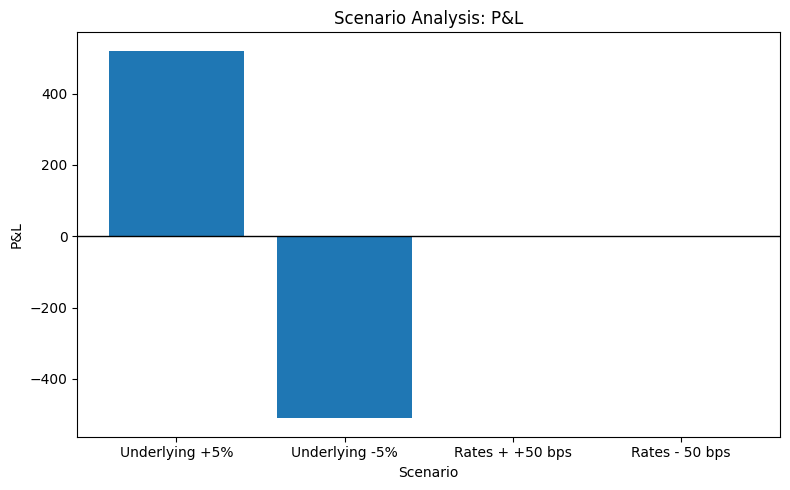

In [30]:
plt.figure (figsize = (8, 5))
plt.bar (scenario_df ["Scenario"], scenario_df ["P&L"])
plt.axhline (0, color = "black", linewidth = 1.0)
plt.title ("Scenario Analysis: P&L")
plt.ylabel ("P&L")
plt.xlabel ("Scenario")
plt.tight_layout ()
plt.show ()